In [1]:
# import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
# import data
df = pd.read_csv(r'tele_churn.csv')

In [38]:
# intro to data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df['TotalCharges'].value_counts()
df['TotalCharges'].isna().sum()


np.int64(0)

In [5]:
# replace the empty space with NaN
import numpy as np
df['TotalCharges']=df['TotalCharges'].replace(" ",np.nan)

# change dtype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [6]:
# confrim dtype
df['TotalCharges'].dtype

dtype('float64')

In [7]:
# check the tenure
df.loc[df['TotalCharges'].isna() , ['TotalCharges','tenure']]

,TotalCharges,tenure
488,NaN,0
753,NaN,0
936,NaN,0
1082,NaN,0
1340,NaN,0
3331,NaN,0
3826,NaN,0
4380,NaN,0
5218,NaN,0
6670,NaN,0


Now fill the nan value of total charges with 0 beacuse there tenure is 0 it means they are new user yet they donot have any bil


In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [9]:
# confrim
df['TotalCharges'].isna().sum()

np.int64(0)

In [11]:
# Get a over View of churn customers
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
# get a percentage
total_counts = len( df['Churn'])
total_counts
no_count_No= len(df[df['Churn']=='No'])
no_count_No
no_count_Yes = len(df[df['Churn']=="Yes"])
# calculate

# no
no_percentage =( no_count_No/total_counts) * 100

yes_percentage =(no_count_Yes / total_counts) *100
print(f'No:     {no_percentage} \n Yes:     {yes_percentage}')

No:     73.4630129206304 
 Yes:     26.536987079369588


In [14]:
# simple
df['Churn'].value_counts(normalize=True)* 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

(array([0, 1]), [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

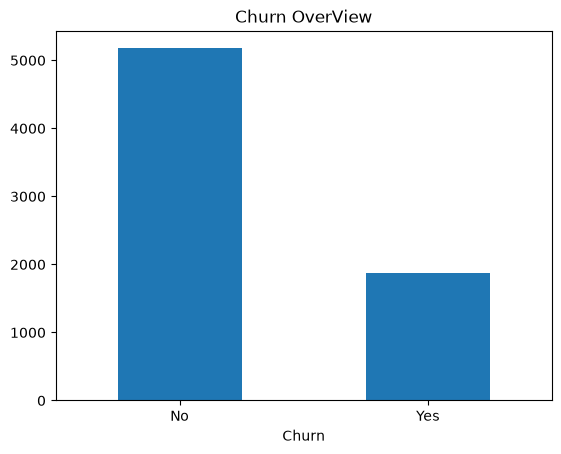

In [15]:
# make a graph
plt.title('Churn OverView')
df['Churn'].value_counts().plot(kind = 'bar')
plt.xticks(rotation =0)

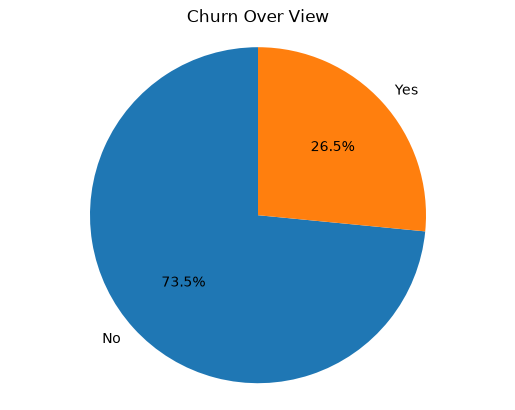

In [16]:
plt.title('Churn Over View')
churn_counts = df['Churn'].value_counts()
plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.axis('equal')
plt.show() 

**Demographic analysis**
Now check the is any affect of customer relation ship churn

In [20]:
# seniorCitizen vs CHurn
# partenr or Depedents vs churn

df.groupby('SeniorCitizen')['Churn'].value_counts()

SeniorCitizen  Churn
0              No       4508
               Yes      1393
1              No        666
               Yes       476
Name: count, dtype: int64

<Axes: title={'center': 'SeniorCitizen  VS Churn'}, xlabel='SeniorCitizen', ylabel='count'>

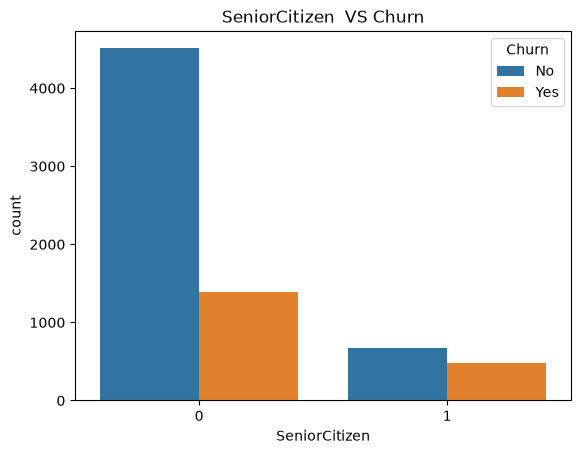

In [21]:
plt.title('SeniorCitizen  VS Churn')
sb.countplot(x=df['SeniorCitizen'] ,hue = df['Churn'])

In [22]:
# partenr vs churn
df.groupby(['Partner'])['Churn'].value_counts()

Partner  Churn
No       No       2441
         Yes      1200
Yes      No       2733
         Yes       669
Name: count, dtype: int64

<Axes: title={'center': ' Partner Vs Churn'}, xlabel='Partner', ylabel='count'>

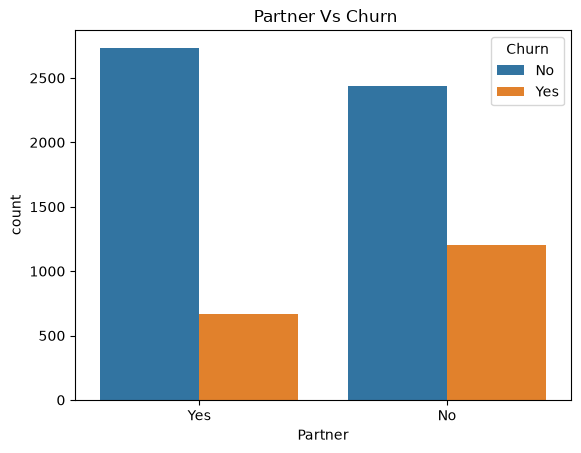

In [26]:
# viz
plt.title(' Partner Vs Churn')
sb.countplot(data = df , x= 'Partner',  hue='Churn')

In [29]:
# churn vs dependes

df.groupby(['Dependents'])['Churn'].value_counts()

Dependents  Churn
No          No       3390
            Yes      1543
Yes         No       1784
            Yes       326
Name: count, dtype: int64

<Axes: title={'center': 'Dependents VS Churn'}, xlabel='Dependents', ylabel='count'>

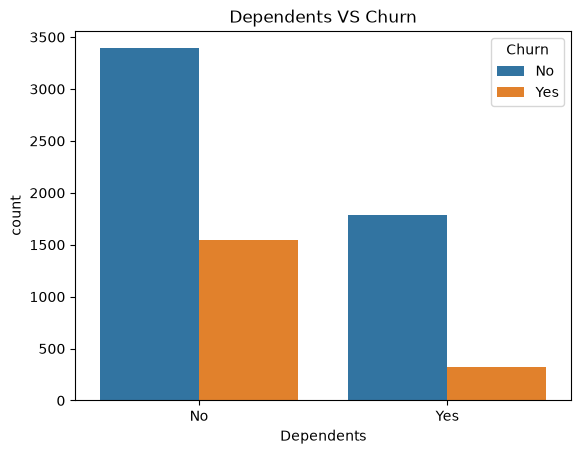

In [32]:
plt.title('Dependents VS Churn')
sb.countplot(x= df['Dependents'] ,  hue=df['Churn'])

In [36]:
# gender

# sb.barplot(data=df , x= 'Gender',y='Churn')
df.groupby(['gender'])['Churn'].value_counts(normalize=True)*100

gender  Churn
Female  No       73.079128
        Yes      26.920872
Male    No       73.839662
        Yes      26.160338
Name: proportion, dtype: float64

<Axes: title={'center': 'Gender Vs Churn Distribution'}, xlabel='gender', ylabel='count'>

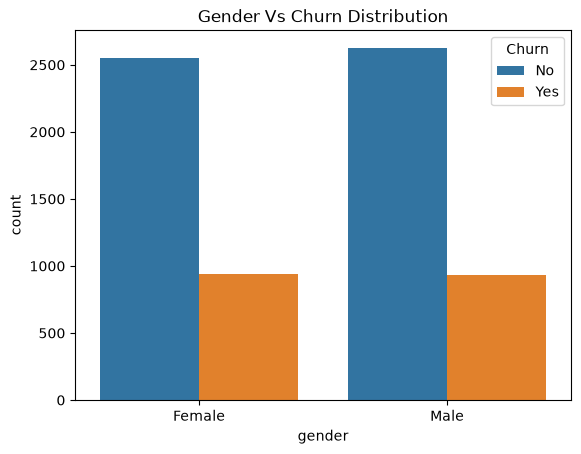

In [37]:
plt.title('Gender Vs Churn Distribution')
sb.countplot(x=df['gender'],hue=df['Churn'])

# 📊 Overall Churn Overview Summary

* **Total Churned Customers 📉:** **26.5%** of customers have left the company.
* **Total Retained Customers 🛡️:** **73.5%** of customers are actively retained.
* **Key Insight 💡:** The dataset is imbalanced, but a **26.5%** churn rate represents a significant revenue loss that requires strategic attention.

---

# 👥 Demographics Analysis Summary

### 1. Senior Citizen vs Churn 👴
* **Non-Senior Citizens (0):** Lower churn rate (Approx **23.6%**).
* **Senior Citizens (1):** Significantly higher churn rate (Approx **41.7%**).
* **Insight:** Senior citizens are considerably more likely to churn than younger customers.

### 2. Partner vs Churn 🤝
* **Without Partner (No):** Higher churn rate (Approx **32.9%**).
* **With Partner (Yes):** Lower churn rate (Approx **19.6%**).
* **Insight:** Customers without a partner tend to switch services more frequently.

### 3. Dependents vs Churn 👨‍👩‍👧
* **Without Dependents (No):** Higher churn rate (Approx **31.2%**).
* **With Dependents (Yes):** Much lower churn rate (Approx **15.4%**).
* **Insight:** Customers with family dependents demonstrate higher loyalty and lower churn.


##  **Services Analysis**

In [35]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [33]:
# check the internet vs  churn
df['InternetService']
df.groupby(['InternetService'])['Churn'].value_counts()

InternetService  Churn
DSL              No       1962
                 Yes       459
Fiber optic      No       1799
                 Yes      1297
No               No       1413
                 Yes       113
Name: count, dtype: int64

In [36]:
# percentage
df.groupby(['InternetService'])['Churn'].value_counts(normalize=True) * 100

InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64

<Axes: title={'center': 'Internet Services VS Churn'}, xlabel='InternetService', ylabel='count'>

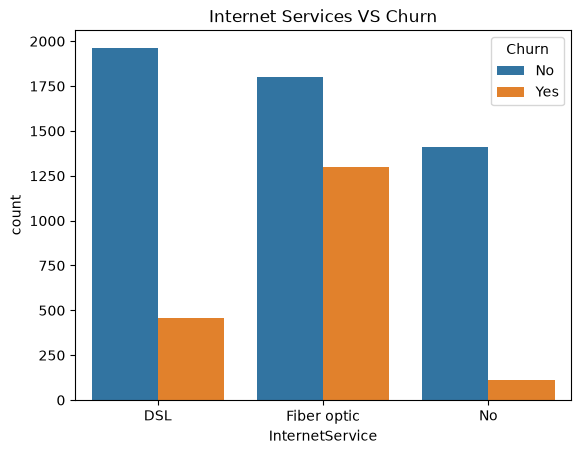

In [34]:
# vizulization
plt.title('Internet Services VS Churn')
sb.countplot(data = df, x='InternetService', hue='Churn')


# 📡 Internet Service Analysis Summary

### Internet Service vs Churn
* **Fiber Optic ⚡:** Highest churn rate (Approx **41.9%** - 1,297 out of 3,096 users).
* **DSL 🔌:** Much lower churn rate (Approx **19.0%** - 459 out of 2,421 users).
* **No Internet Service 🚫:** Lowest churn rate (Approx **7.4%** - 113 out of 1,526 users).

### Key Insights 💡
* **Fiber Optic Risk:** Despite offering high speeds, Fiber Optic has an alarming churn rate. This points toward potential issues with high monthly charges, service disruption, or poor customer support for premium users.
* **DSL Retention:** DSL customers exhibit stronger loyalty, likely due to affordable pricing and settled expectations.

In [37]:
# onlineSecurity analysis
df.groupby(['OnlineSecurity'])['Churn'].value_counts()

OnlineSecurity       Churn
No                   No       2037
                     Yes      1461
No internet service  No       1413
                     Yes       113
Yes                  No       1724
                     Yes       295
Name: count, dtype: int64

In [38]:
df.groupby(['OnlineSecurity'])['Churn'].value_counts(normalize=True)*100

OnlineSecurity       Churn
No                   No       58.233276
                     Yes      41.766724
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       85.388806
                     Yes      14.611194
Name: proportion, dtype: float64

<Axes: title={'center': 'Online Security Vs Churn'}, xlabel='OnlineSecurity', ylabel='count'>

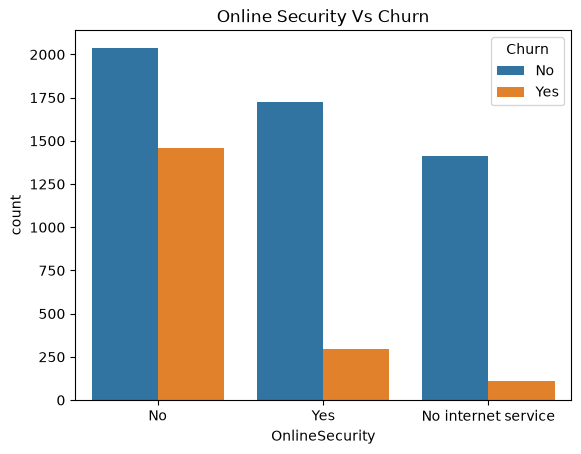

In [15]:
plt.title('Online Security Vs Churn')
sb.countplot(x= df['OnlineSecurity'], hue = df['Churn'],palette='tab10')

# 🔐 Online Security Analysis Summary

### Online Security vs Churn
* **No Online Security ❌:** Highest churn rate (Approx **41.8%** - 1,461 churned vs 2,037 stayed).
* **With Online Security 🛡️:** Very low churn rate (Approx **14.6%** - 295 churned vs 1,724 stayed).
* **No Internet Service 🚫:** Lowest churn rate (Approx **7.4%** - 113 churned vs 1,413 stayed).

### Key Insights 💡
* **Security Retains Users:** Customers without Online Security are almost **3x more likely to churn** compared to those who have it enabled.
* **Value-Added Service:** Online Security acts as a strong "retention hook"—adding value to the core service and keeping users attached to the platform.


In [ ]:
# contract analysis
pd.crosstab(df['Contract'],df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [14]:
pd.crosstab(df['Contract'],df['Churn'], normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


(array([0, 1, 2]),
 [Text(0, 0, 'Month-to-month'),
  Text(1, 0, 'One year'),
  Text(2, 0, 'Two year')])

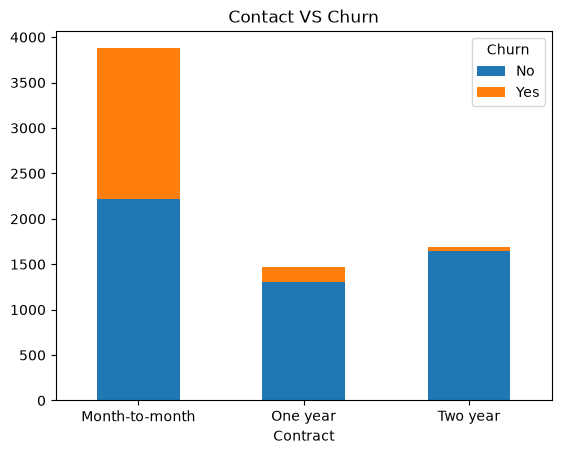

In [ ]:
# graph
pd.crosstab(df['Contract'],df['Churn']).plot(kind='bar',stacked=True,title='Contact VS Churn')
plt.xticks(rotation=0)


# 📑 Contract Type Analysis Summary

### Contract vs Churn
* **Month-to-month 📅:** Highest churn rate (Approx **42.7%** - 1,655 out of 3,875 users).
* **One year ⏳:** Low churn rate (Approx **11.3%** - 166 out of 1,473 users).
* **Two year 🔒:** Extremely low churn rate (Approx **2.8%** - 48 out of 1,695 users).

### Key Insights 💡
* **Contract Length Direct Impact:** Long-term contracts significantly improve customer retention.
* **Risk Factor:** Month-to-month customers carry the highest risk of churn due to zero lock-in commitment.
*

In [16]:
# payment method analysis
pd.crosstab(df['PaymentMethod'],df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [17]:
# percenatge
pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Bank transfer (automatic)'),
  Text(1, 0, 'Credit card (automatic)'),
  Text(2, 0, 'Electronic check'),
  Text(3, 0, 'Mailed check')])

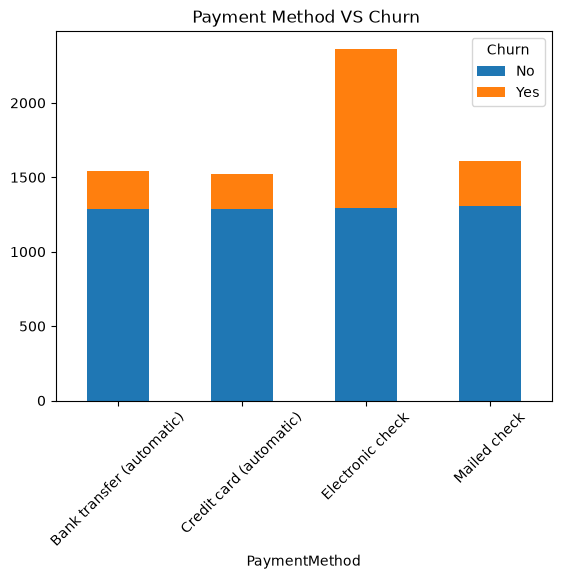

In [24]:
# df.groupby(['PaymentMethod'])['Churn'].value_counts(normalize=True).plot(kind='bar',stacked=True,title='Payment Method VS Churn')
pd.crosstab(df['PaymentMethod'],df['Churn']).plot(kind='bar',stacked=True,title=" Payment Method VS Churn")
plt.xticks(rotation=45)


# 💳 Payment Method Analysis Summary

### Payment Method vs Churn
* **Electronic Check 💻:** Highest churn rate (Approx **45.3%** - 1,071 out of 2,365 users).
* **Mailed Check ✉️:** Moderate churn rate (Approx **19.1%** - 308 out of 1,612 users).
* **Bank Transfer (Automatic) 🏦:** Low churn rate (Approx **16.7%** - 258 out of 1,544 users).
* **Credit Card (Automatic) 💳:** Lowest churn rate (Approx **15.2%** - 232 out of 1,522 users).

### Key Insights 💡
* **Manual vs Automatic:** Customers using automatic payment methods show significantly higher retention.
* **Friction Risk:** Manual payment methods like Electronic Check create recurring decision points for users every month, making them more prone to churn.
*

# **NUMERICAL ANALYSIS**

In [17]:
df['tenure'].value_counts()

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

<Figure size 400x300 with 0 Axes>

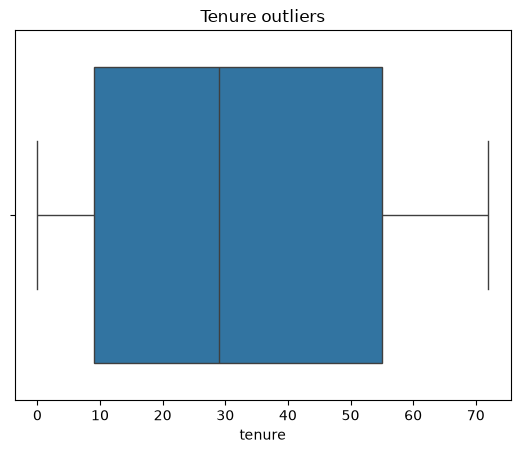

In [20]:
plt.title('Tenure outliers')
sb.boxplot(x=df['tenure'])
plt.Figure(figsize=(4,3))

<Axes: title={'center': ' Customer Tenure Distribution'}, xlabel='tenure', ylabel='Count'>

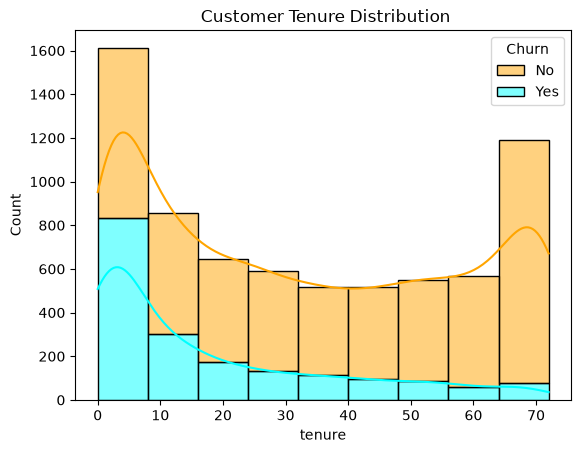

In [21]:
plt.title(' Customer Tenure Distribution')
sb.histplot(data = df ,x='tenure',hue='Churn',kde=True,bins=9,palette=['orange','cyan'],multiple='stack')

<Figure size 400x200 with 0 Axes>

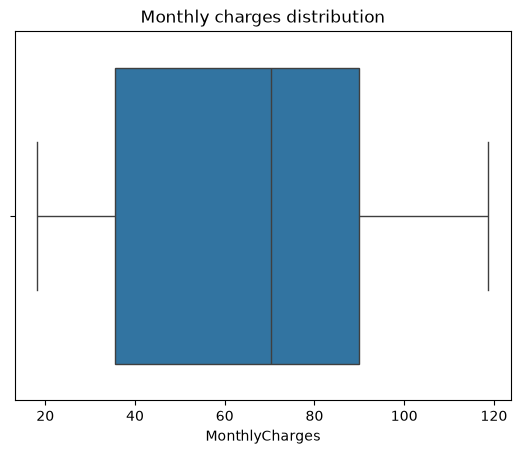

In [23]:
# monthly charges
plt.title('Monthly charges distribution')
sb.boxplot(x=df['MonthlyCharges'])
plt.Figure(figsize=(4,2))

In [27]:
df['MonthlyCharges'].value_counts()

MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
19.70     43
          ..
72.00      1
108.35     1
63.10      1
44.20      1
78.70      1
Name: count, Length: 1585, dtype: int64

<Axes: title={'center': 'Monthly Charges Distribution'}, xlabel='MonthlyCharges', ylabel='Count'>

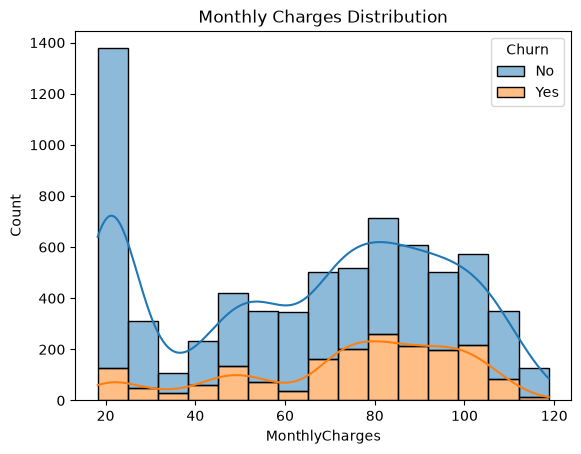

In [28]:
# hisplot
plt.title('Monthly Charges Distribution')
sb.histplot(data= df, x='MonthlyCharges',hue='Churn',multiple='stack',bins=15,kde=True,palette=['#1f77b4','#ff7f0e'])

# 📈 Numerical Features Analysis Summary

### 1. Tenure vs Churn ⏳
* **High Risk Zone:** Initial months (0–12 months) show the highest churn rate.
* **Loyalty Zone:** Customers with tenure > 60 months rarely churn.

### 2. Monthly Charges vs Churn 💵
* **High Risk Zone:** Charges between $70 – $100+ have significantly higher churn.
* **Low Risk Zone:** Low charges (~$20) show very high customer retention.
*

<Axes: title={'center': ' Tenure Vs Monthly Charges'}, xlabel='tenure', ylabel='MonthlyCharges'>

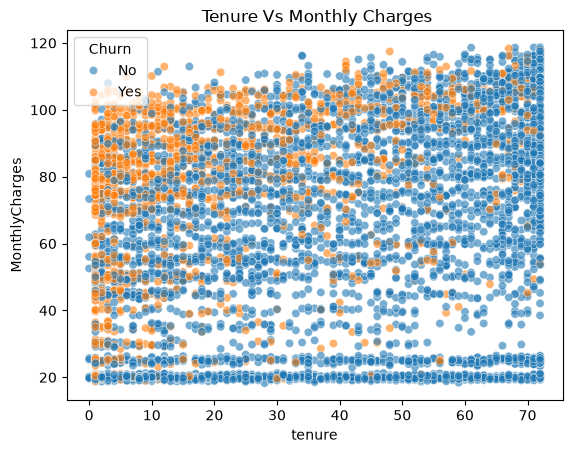

In [29]:
# check the starting months bills by churn
plt.title(' Tenure Vs Monthly Charges')
sb.scatterplot(data=df , x='tenure', y='MonthlyCharges',hue='Churn',alpha=0.6)

# 📈 Numerical Features Analysis Summary

### 1. Tenure vs Churn ⏳
* **High Risk Zone:** Initial months (0–12 months) show the highest churn rate.
* **Loyalty Zone:** Customers with tenure > 60 months rarely churn.

### 2. Monthly Charges vs Churn 💵
* **High Risk Zone:** Charges between $70 – $100+ have significantly higher churn.
* **Low Risk Zone:** Low charges (~$20) show very high customer retention.
*

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

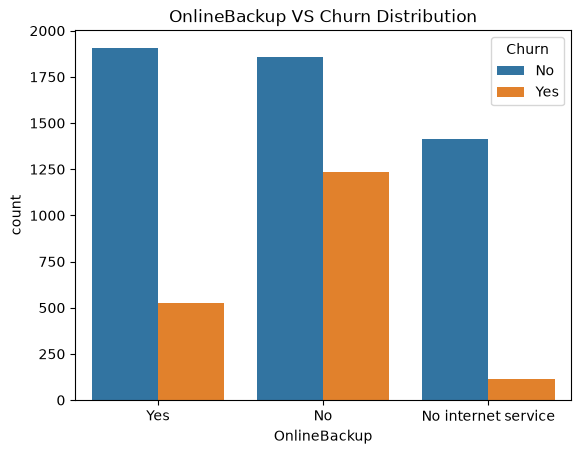

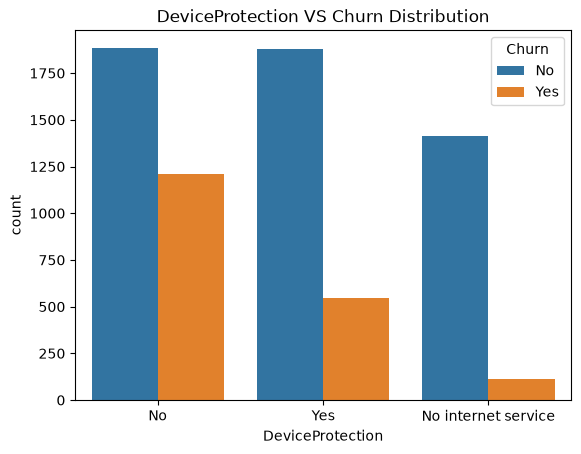

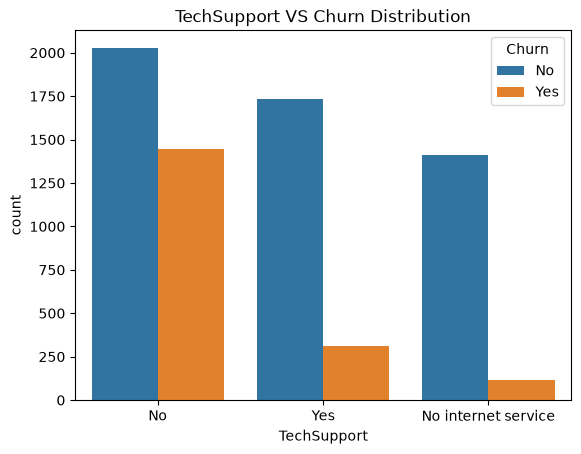

In [40]:
# services
Target=['OnlineBackup','DeviceProtection','TechSupport']

for i in Target:
    title=f'{i} VS Churn Distribution'
    plt.title(title)
    sb.countplot(x=df[i], hue=df['Churn'])
    plt.show()

# 🛠️ Additional Services vs Churn Summary

### Key Findings 🔍
* **Online Backup 💾:** Customers without Online Backup (`No`) show a significantly higher churn rate compared to those who have it.
* **Device Protection 🛡️:** Customers without Device Protection (`No`) have a noticeably higher churn count.
* **Tech Support 🛠️:** Lack of Tech Support is another major driver of churn; customers with `No` Tech Support leave at a much higher rate.

### Core Business Takeaway 💡
* **Add-on Services Prevent Churn:** Value-added services (Security, Backup, Protection, Tech Support) build customer retention. When customers don't subscribe to these add-ons, their likelihood of churning increases sharply.
*

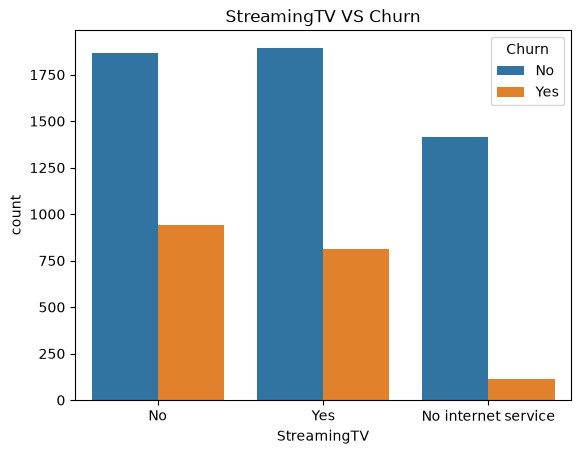

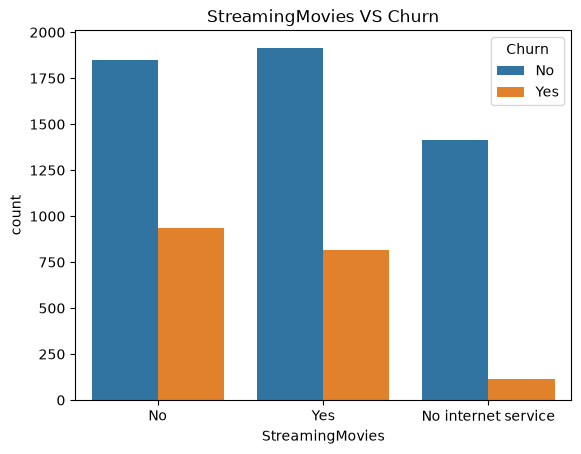

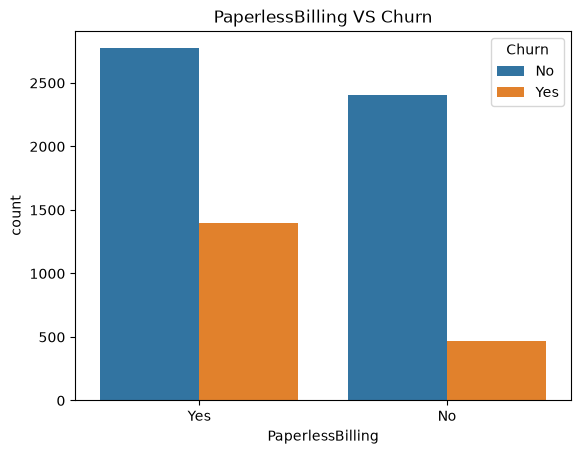

In [44]:
# remain col services and bills
Targe=['StreamingTV','StreamingMovies','PaperlessBilling']
for x in Targe:
    til=f'{ x} VS Churn'
    plt.title(til)
    sb.countplot(x=df[x], hue= df['Churn'])
    plt.show()

# 📄 Paperless Billing Analysis Summary

### Key Findings 🔍
* **Higher Churn Rate ⚠️:** Customers enrolled in `PaperlessBilling = Yes` show a significantly higher churn count compared to those with paper billing (`No`).

### Behavioral Insight 💡
* **Digital Friction ⚡:** Tech-savvy users who receive digital bills notice high charges ($80–$100+) quickly and face fewer obstacles when switching to a different provider online.
*

# 📄 Paperless Billing Analysis Summary

### Key Findings 🔍
* **Higher Churn Rate ⚠️:** Customers enrolled in `PaperlessBilling = Yes` show a significantly higher churn count compared to those with paper billing (`No`).

### Behavioral Insight 💡
* **Digital Friction ⚡:** Tech-savvy users who receive digital bills notice high charges ($80–$100+) quickly and face fewer obstacles when switching to a different provider online.
*

# ⚙️ Strategy Execution Roadmap

### Phase 1: High-Risk Customer Identification (Days 1–30)
* Filter database for new customers (Tenure < 10 months) with High Monthly Charges ($80+) on Month-to-Month contracts.
* Target this specific segment as the primary high-risk churn pool.

### Phase 2: Add-on Bundling & Onboarding (Days 31–60)
* Automatically include basic Tech Support or Online Security as a free 3-month trial for all new high-tier subscribers.
* Restructure month-to-month plan sign-ups to highlight bundled security features at checkout.

### Phase 3: Digital Billing Optimization (Days 61–90)
* Redesign paperless billing email templates to display account usage highlights and active subscription value alongside the total cost.
* Introduce automated billing alerts when a monthly bill exceeds normal thresholds, offering a loyalty discount before customer cancellation.
*